上游代码：`_DiffPDDeformability.py`

In [40]:
import numpy as np
import numpy.typing as npt
from typing import Tuple, List, Union
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import rcParams
import matplotlib.patches as patches


# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [19]:
def approx_elliptic(j:npt.NDArray, r_vec:npt.NDArray) -> dict:
    # r1, r2 = np.array([0, -1]), np.array([0, 1])    # rihgt hand side
    r1, r2 = r_vec
    trans_r = np.vstack([np.dot(j, r1), np.dot(j, r2)])
    print(trans_r)

    u, s, vh = np.linalg.svd(j)
    v = vh.T
    # 是否出现了u和v是否有翻转的情况
    yflip = np.array([[1, 0], [0, -1]])
    if np.linalg.det(u) < 0 and np.linalg.det(vh) < 0:
        u_yflip = u @ yflip
        v_yflip = v @ yflip
    elif np.linalg.det(u) < 0:
        raise ValueError('u is not a rotation matrix')
    elif np.linalg.det(v) < 0:
        raise ValueError('v is not a rotation matrix')
    else:
        u_yflip = u
        v_yflip = v

    # 未旋转椭圆的起点和终点
    r1_tmp = np.dot(np.diag(s) @ v_yflip.T, r1)
    r2_tmp = np.dot(np.diag(s) @ v_yflip.T, r2)

    ang1 = np.degrees(np.arctan2(r1_tmp[1], r1_tmp[0]))
    ang2 = np.degrees(np.arctan2(r2_tmp[1], r2_tmp[0]))

    rot_ang = np.degrees(np.arctan2(u_yflip[1,0], u_yflip[0,0]))
    print(f"Ellipse Rotation Angle: {rot_ang}; Angle Interval: {ang1} ~ {ang2}; Axis: {s}; Area: {np.pi*s[0]*s[1]}")

    return {'s': s, 'rot': rot_ang, 'arc_range': [ang1, ang2], 'trans_r': trans_r}

In [ ]:
def ellipse_simplify(j, r_vec:npt.NDArray, N:int)->List[npt.NDArray]:
    # 将椭圆弧线段化为N段
    # r1, r2 = np.array([0, -1]), np.array([0, 1])    # rihgt hand side
    r1, r2 = r_vec
    dot_product = np.dot(r1, r2)
    theta = np.arccos(dot_product)
    
    r = []
    r.append(np.zeros(2))
    # r += [np.dot(j, r1*(i+1)/6)for i in range(5)]

    t_values = np.linspace(0, 1, N)
    for t in t_values:
        rot_ang = t * theta
        rot_mat = np.array([[np.cos(rot_ang), -np.sin(rot_ang)], [np.sin(rot_ang), np.cos(rot_ang)]])
        r_tmp = np.dot(rot_mat, r1)
        r.append(np.dot(j, r_tmp))
    
    # r += [np.dot(j, r2*(i+1)/6)for i in range(5)]

    return r

In [ ]:
def plot_ellipse(j, r_vec:npt.NDArray, ax:plt.Axes, N:int)->List[npt.NDArray]:
    dict = approx_elliptic(j, r_vec)
    s = dict['s']
    rot_ang = dict['rot']
    arc_range = dict['arc_range']
    start_d, end_d = dict['trans_r']

    r = ellipse_simplify(j, r_vec, N)
    r_np = np.array(r)

    ellipse_arc = patches.Arc((0., 0.), s[0]*2, s[1]*2, angle=rot_ang, theta1=arc_range[0], theta2=arc_range[1], color='k', linewidth=2)
    ellipse_arc.set_zorder(2)

    ax.add_patch(ellipse_arc)
    ax.plot([0., start_d[0]], [0., start_d[1]], color='k', linewidth=2, zorder=2)
    ax.plot([0., end_d[0]], [0., end_d[1]], color='k', linewidth=2, zorder=2)
    ax.scatter(0, 0, color='r', s=25, zorder=3)

    ax.scatter(r_np[:,0], r_np[:,1], color='b', s=25, zorder=3)

    ax.set_xlim([-1., 1.])
    ax.set_ylim([-1., 1.])
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, zorder=0)

    ax.invert_yaxis()

    return r

In [55]:
def plot_polygon(vertices, ax:plt.Axes, label, color, line_style='-'):
    vertices = np.vstack([vertices, vertices[0]])                   # 闭合多边形
    ax.plot(vertices[:, 0], vertices[:, 1], label=label, color=color, lw=1.5, linestyle=line_style, marker='')
    ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.2, color=color)

In [34]:
def polygon_area(vertices):
    """
    计算多边形面积
    :param vertices: 多边形顶点的列表 [array([x1, y1]), array([x2, y2]), ..., array([xn, yn])]
    :return: 多边形的面积
    """
    n = len(vertices)
    area = 0
    for i in range(n):
        x1, y1 = vertices[i]
        x2, y2 = vertices[(i + 1) % n]
        area += x1 * y2 - x2 * y1
    return abs(area) / 2

In [ ]:
def mincowski_add(poly1:List[npt.NDArray], poly2:List[npt.NDArray]) -> List[npt.NDArray]:
    results = []
    n1, n2 = len(poly1), len(poly2)
    # i, j 分别是两个多边形的当前顶点索引
    i, j = 0, 0

    while i < n1 or j < n2:
        results.append(poly1[i % n1] + poly2[j % n2])
        
        # 计算边的方向向量
        edge1 = poly1[(i + 1) % n1] - poly1[i % n1]
        edge2 = poly2[(j + 1) % n2] - poly2[j % n2]

        # 比较当前边的角度，选择较小的角度
        cross_product = np.cross(edge1, edge2)
        if cross_product > 0:
            i += 1
        elif cross_product < 0:
            j += 1
        else:
            i += 1
            j += 1

    return results

In [41]:
def contour_xaxis_intersect(results:List[npt.NDArray]):
    # 求轮廓与X轴相交的正半轴交点的X值
    # 假设 results 是包含轮廓所有点的集合，例如 [(x1, y1), (x2, y2), ...]

    # 提取 x 和 y 坐标
    x_coords = [point[0] for point in results]
    y_coords = [point[1] for point in results]

    # 寻找与 X 轴正半轴的交点
    intersections = []
    for i in range(len(y_coords) - 1):
        # 检查相邻点是否跨越了 X 轴
        if y_coords[i] * y_coords[i + 1] < 0:
            # 线性插值计算交点
            x_intersect = x_coords[i] - y_coords[i] * (x_coords[i + 1] - x_coords[i]) / (y_coords[i + 1] - y_coords[i])
            if x_intersect > 0:  # 只保留正半轴的交点
                intersections.append(x_intersect)

    # 找到最小的正 X 轴交点
    if intersections:
        x_intersection = min(intersections)
        print("红色轮廓与 X 轴正半轴的交点 X 值为:", x_intersection)
    else:
        print("没有找到与 X 轴正半轴的交点")

In [104]:
marker_idx_list = [58, 59, 73]
barycentric = [0.04519048, 0.3539601, 0.60084942]
mani_list = [8, 134]

dim:int = 2
mani_dx_dy = np.zeros((dim, dim*len(mani_list)))

# 读取数据
for i, idx in enumerate(mani_list):
    dx_dy_tmp = np.loadtxt(f'dx_dy-contact_idx_{idx}.csv', delimiter=',')
    for j, marker_idx in enumerate(marker_idx_list):
        mani_dx_dy[:, i*dim:i*dim+dim] += barycentric[j] * dx_dy_tmp[marker_idx*dim:marker_idx*dim+dim, :]
    
j1 = mani_dx_dy[:, 0:2]
j2 = mani_dx_dy[:, 2:4]

[[-0.37958925 -0.57540435]
 [ 0.37958925  0.57540435]]
Ellipse Rotation Angle: -110.44275166646364; Angle Interval: -12.969737575445336 ~ 167.03026242455468; Axis: [0.8833116  0.23825369]; Area: 0.6611552299051258
[[-0.20691995 -0.74926296]
 [ 0.20691995  0.74926296]]
Ellipse Rotation Angle: 75.96898176266075; Angle Interval: 178.5927470867362 ~ -1.4072529132638012; Axis: [0.7786401  0.30128643]; Area: 0.7369978216252681


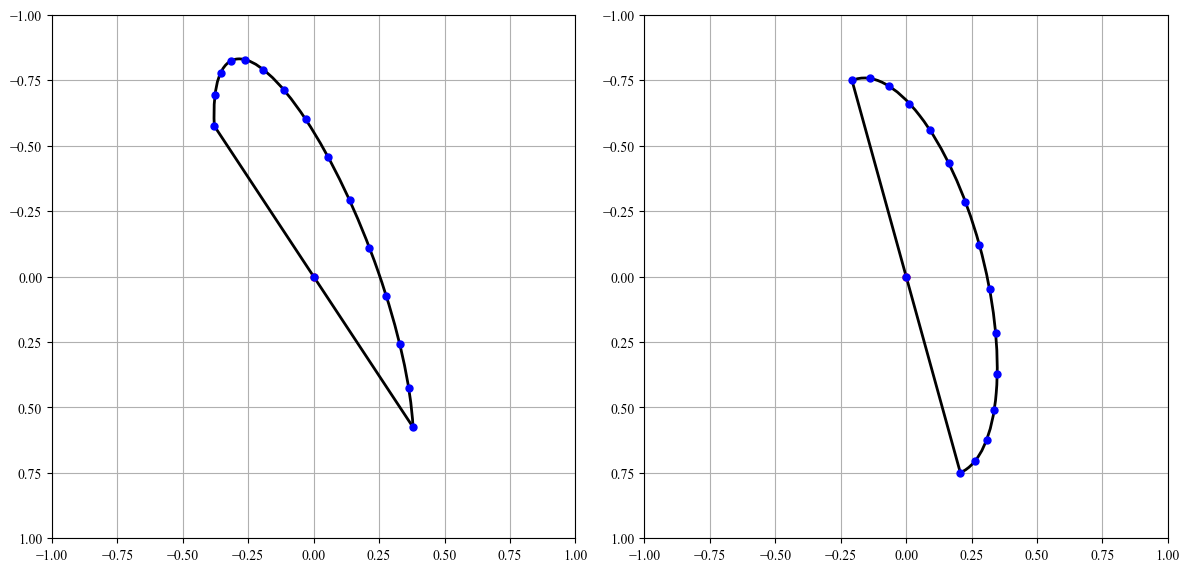

In [105]:
fig = plt.figure(figsize=(12, 8), dpi=100)
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
r1 = plot_ellipse(j1, np.array([[-1, 0], [1, 0]]), ax1, 15)

ax2 = fig.add_subplot(gs[0, 1])
r2 = plot_ellipse(j2, np.array([[0, -1], [0, 1]]), ax2, 15)

plt.tight_layout()

Minkowski Sum Area: 1.643139128708913
红色轮廓与 X 轴正半轴的交点 X 值为: 0.570179541547919


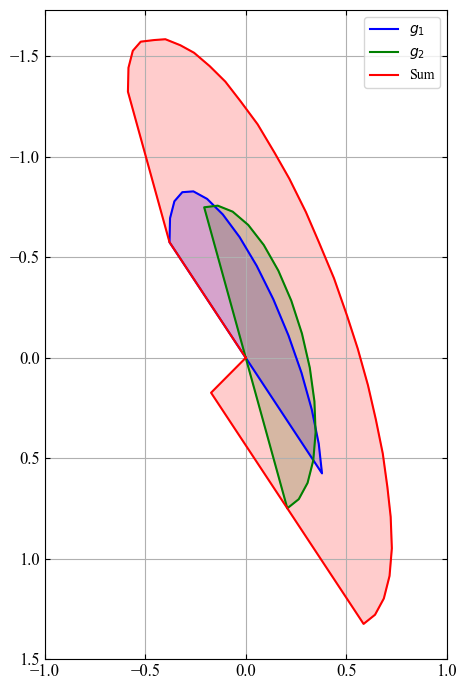

In [106]:
poly1 = r1
poly2 = r2
result = mincowski_add(poly1, poly2)

fig = plt.figure(figsize=(5, 7), dpi=100)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])
plot_polygon(poly1, ax, '$g_1$', 'blue')
plot_polygon(poly2, ax, '$g_2$', 'green')
plot_polygon(result, ax, 'Sum', 'red')

# ax.set_title('Manipulation Graph of $s_1$', fontsize=14)
# ax.set_xlabel('X', fontsize=12)
# ax.set_ylabel('Y', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
ax.legend(loc='best', fontsize=10)
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
tick_interval = 0.5
current_xticks = [-1, 1.25] #ax.get_xticks()
current_yticks = [-1.5, 1.75] #ax.get_yticks()
ax.set_xticks(np.arange(current_xticks[0], current_xticks[-1], tick_interval))
ax.set_yticks(np.arange(current_yticks[0], current_yticks[-1], tick_interval))
ax.invert_yaxis()

plt.tight_layout()
# fig.savefig('minkowski_sum.png', transparent=True, dpi=300)

area = polygon_area(result)
print(f'Minkowski Sum Area: {area}')

contour_xaxis_intersect(result)

---

In [110]:
marker_idx_list = [58, 59, 73]
barycentric = [0.04519048, 0.3539601, 0.60084942]
mani_list = [14, 134]

dim:int = 2
mani_dx_dy = np.zeros((dim, dim*len(mani_list)))

# 读取数据
for i, idx in enumerate(mani_list):
    dx_dy_tmp = np.loadtxt(f'dx_dy-contact_idx_{idx}.csv', delimiter=',')
    for j, marker_idx in enumerate(marker_idx_list):
        mani_dx_dy[:, i*dim:i*dim+dim] += barycentric[j] * dx_dy_tmp[marker_idx*dim:marker_idx*dim+dim, :]
    
j1 = mani_dx_dy[:, 0:2]
j2 = mani_dx_dy[:, 2:4]

[[ 0.0277395  -0.60393993]
 [-0.0277395   0.60393993]]
Ellipse Rotation Angle: 90.58176091209447; Angle Interval: -177.95196255429298 ~ 2.048037445707047; Axis: [0.60634469 0.25654186]; Area: 0.48868352704121093
[[-0.20691995 -0.74926296]
 [ 0.20691995  0.74926296]]
Ellipse Rotation Angle: 75.96898176266075; Angle Interval: 178.5927470867362 ~ -1.4072529132638012; Axis: [0.7786401  0.30128643]; Area: 0.7369978216252681


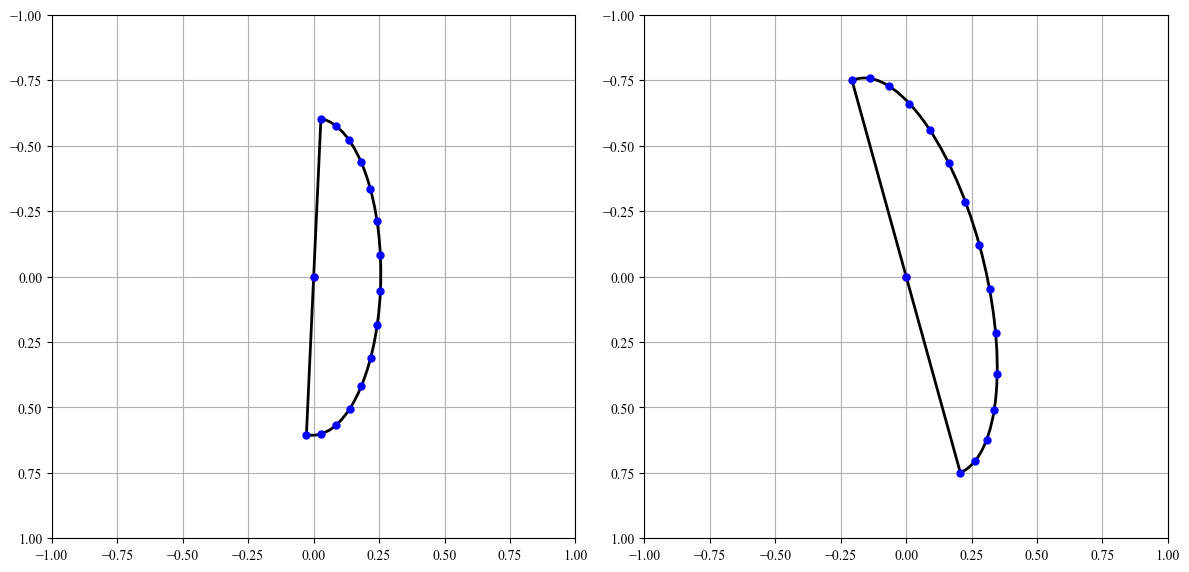

In [111]:
fig = plt.figure(figsize=(12, 8), dpi=100)
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
r1 = plot_ellipse(j1, np.array([[0, -1], [0, 1]]), ax1, 15)

ax2 = fig.add_subplot(gs[0, 1])
r2 = plot_ellipse(j2, np.array([[0, -1], [0, 1]]), ax2, 15)

plt.tight_layout()

Minkowski Sum Area: 1.4544375161037613
红色轮廓与 X 轴正半轴的交点 X 值为: 0.5833385020376336


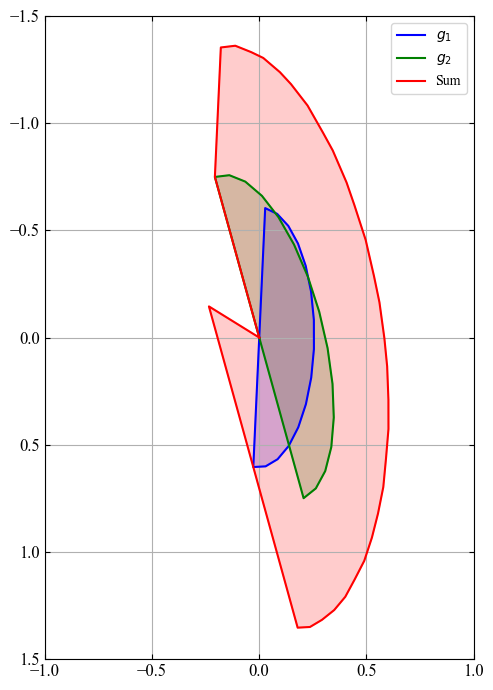

In [112]:
poly1 = r1
poly2 = r2
result = mincowski_add(poly1, poly2)

fig = plt.figure(figsize=(5, 7), dpi=100)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])
plot_polygon(poly1, ax, '$g_1$', 'blue')
plot_polygon(poly2, ax, '$g_2$', 'green')
plot_polygon(result, ax, 'Sum', 'red')

# ax.set_title('Manipulation Graph of $s_1$', fontsize=14)
# ax.set_xlabel('X', fontsize=12)
# ax.set_ylabel('Y', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
ax.legend(loc='best', fontsize=10)
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
tick_interval = 0.5
current_xticks = [-1, 1.25] #ax.get_xticks()
current_yticks = [-1.5, 1.75] #ax.get_yticks()
ax.set_xticks(np.arange(current_xticks[0], current_xticks[-1], tick_interval))
ax.set_yticks(np.arange(current_yticks[0], current_yticks[-1], tick_interval))
ax.invert_yaxis()

plt.tight_layout()
# fig.savefig('minkowski_sum.png', transparent=True, dpi=300)

area = polygon_area(result)
print(f'Minkowski Sum Area: {area}')

contour_xaxis_intersect(result)

---

In [114]:
marker_idx_list = [58, 59, 73]
barycentric = [0.04519048, 0.3539601, 0.60084942]
mani_list = [14, 224]

dim:int = 2
mani_dx_dy = np.zeros((dim, dim*len(mani_list)))

# 读取数据
for i, idx in enumerate(mani_list):
    dx_dy_tmp = np.loadtxt(f'dx_dy-contact_idx_{idx}.csv', delimiter=',')
    for j, marker_idx in enumerate(marker_idx_list):
        mani_dx_dy[:, i*dim:i*dim+dim] += barycentric[j] * dx_dy_tmp[marker_idx*dim:marker_idx*dim+dim, :]
    
j1 = mani_dx_dy[:, 0:2]
j2 = mani_dx_dy[:, 2:4]

[[ 0.0277395  -0.60393993]
 [-0.0277395   0.60393993]]
Ellipse Rotation Angle: 90.58176091209447; Angle Interval: -177.95196255429298 ~ 2.048037445707047; Axis: [0.60634469 0.25654186]; Area: 0.48868352704121093
[[-0.14702024 -0.48486869]
 [ 0.14702024  0.48486869]]
Ellipse Rotation Angle: 73.11331941560279; Angle Interval: -179.981494526803 ~ 0.018505473196998194; Axis: [0.50667023 0.05641972]; Area: 0.08980617091298664


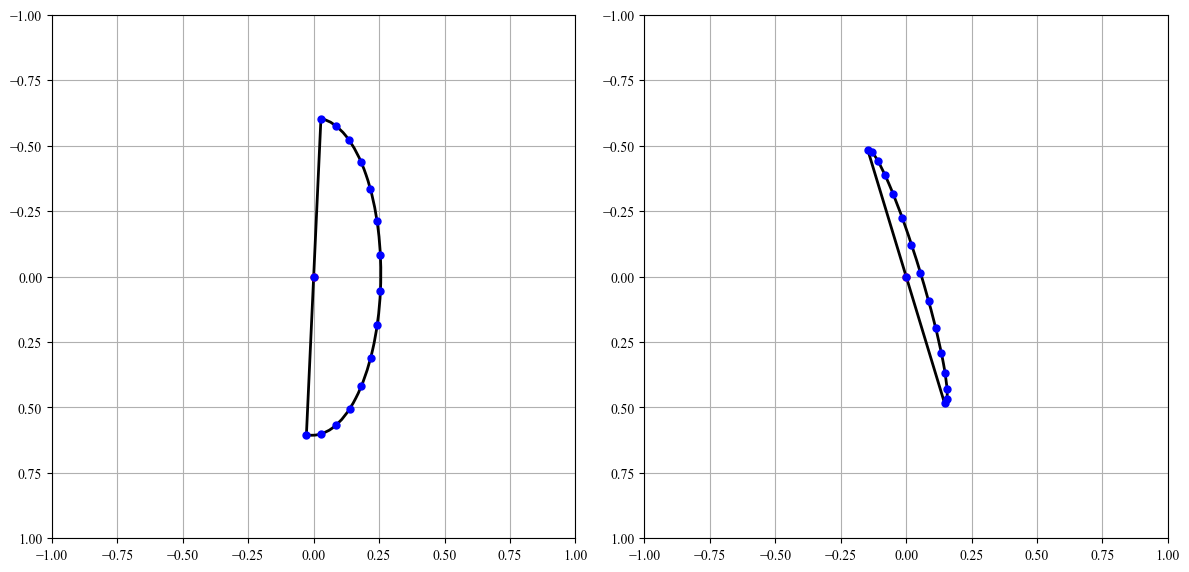

In [115]:
fig = plt.figure(figsize=(12, 8), dpi=100)
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
r1 = plot_ellipse(j1, np.array([[0, -1], [0, 1]]), ax1, 15)

ax2 = fig.add_subplot(gs[0, 1])
r2 = plot_ellipse(j2, np.array([[0, -1], [0, 1]]), ax2, 15)

plt.tight_layout()

Minkowski Sum Area: 0.7632792679077477
红色轮廓与 X 轴正半轴的交点 X 值为: 0.36009390372456035


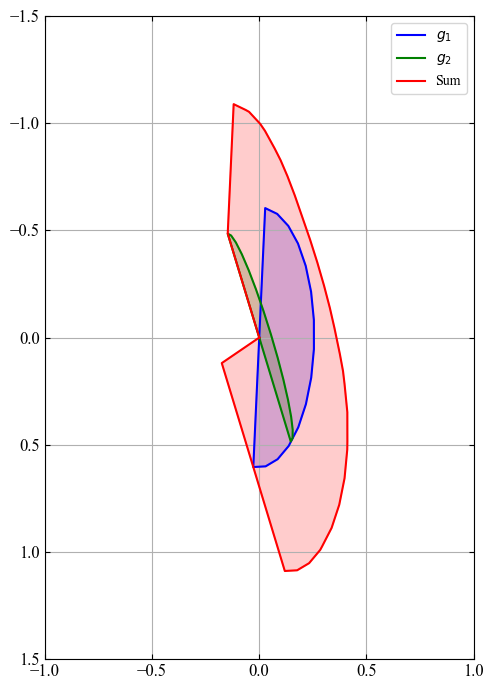

In [116]:
poly1 = r1
poly2 = r2
result = mincowski_add(poly1, poly2)

fig = plt.figure(figsize=(5, 7), dpi=100)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])
plot_polygon(poly1, ax, '$g_1$', 'blue')
plot_polygon(poly2, ax, '$g_2$', 'green')
plot_polygon(result, ax, 'Sum', 'red')

# ax.set_title('Manipulation Graph of $s_1$', fontsize=14)
# ax.set_xlabel('X', fontsize=12)
# ax.set_ylabel('Y', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
ax.legend(loc='best', fontsize=10)
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
tick_interval = 0.5
current_xticks = [-1, 1.25] #ax.get_xticks()
current_yticks = [-1.5, 1.75] #ax.get_yticks()
ax.set_xticks(np.arange(current_xticks[0], current_xticks[-1], tick_interval))
ax.set_yticks(np.arange(current_yticks[0], current_yticks[-1], tick_interval))
ax.invert_yaxis()

plt.tight_layout()
# fig.savefig('minkowski_sum.png', transparent=True, dpi=300)

area = polygon_area(result)
print(f'Minkowski Sum Area: {area}')

contour_xaxis_intersect(result)

---
用于论文绘图

Minkowski Sum Area: 0.7632792679077477
红色轮廓与 X 轴正半轴的交点 X 值为: 0.36009390372456035


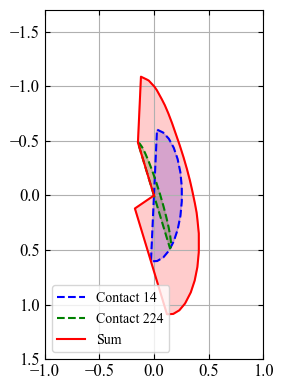

In [117]:
poly1 = r1
poly2 = r2
result = mincowski_add(poly1, poly2)

fig = plt.figure(figsize=(3, 4), dpi=100)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])
plot_polygon(poly1, ax, 'Contact 14', 'blue', '--')
plot_polygon(poly2, ax, 'Contact 224', 'green', '--')
plot_polygon(result, ax, 'Sum', 'red', '-')

# ax.set_title('Manipulation Graph of $s_1$', fontsize=14)
# ax.set_xlabel('X', fontsize=12)
# ax.set_ylabel('Y', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
ax.legend(loc='best', fontsize=10)
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
tick_interval = 0.5
current_xticks = [-1, 1.25] #ax.get_xticks()
current_yticks = [-2., 1.6] #ax.get_yticks()
ax.set_xticks(np.arange(current_xticks[0], current_xticks[-1], tick_interval))
ax.set_yticks(np.arange(current_yticks[0], current_yticks[-1], tick_interval))
ax.set_ylim([-1.7, 1.5])
ax.invert_yaxis()

plt.tight_layout()
fig.savefig('multi-contact-mani3.svg', transparent=True, dpi=300, bbox_inches='tight')

area = polygon_area(result)
print(f'Minkowski Sum Area: {area}')

contour_xaxis_intersect(result)